In [86]:
import pandas as pd
import numpy as np
from pathlib import Path
from sortedcontainers import SortedDict
import matplotlib.pyplot as plt

In [87]:
selected_options = [f.stem for f in Path('/Users/suryasridhar/GitHubProject/ncsu_finmath_summer_2026/OptionsData').rglob('*.data')]

In [161]:
import time

import requests
import pandas as pd

def get_btc_spot_15min(start_ts, end_ts):
    url      = "https://www.okx.com/api/v5/market/history-candles"
    all_data = []
    after    = end_ts
    
    while True:
        params = {
            "instId": "BTC-USDT",
            "bar"   : "15m",
            "after" : str(after),
            "limit" : "100"
        }
        resp = requests.get(url, params=params).json()
        data = resp.get('data', [])
        
        if not data:
            break
        
        all_data.extend(data)
        oldest = int(data[-1][0])
        
        if oldest <= start_ts:
            break
        
        after = oldest
        time.sleep(0.1)
    
    df = pd.DataFrame(all_data, columns=[
        'ts','open','high','low','close','vol','volCcy','volCcyQuote','confirm'
    ])
    df['ts']    = pd.to_datetime(df['ts'].astype(int), unit='ms')
    df['close'] = df['close'].astype(float)
    df = df[df['ts'] >= pd.Timestamp(start_ts, unit='ms')]
    df = df.sort_values('ts').reset_index(drop=True)
    
    return df[['ts', 'close']].rename(columns={'close': 'btc_spot'})

start = int(pd.Timestamp('2026-05-01').timestamp() * 1000)
end   = int(pd.Timestamp('2026-05-16').timestamp() * 1000)

btc_spot = get_btc_spot_15min(start, end)
print(f"Got {len(btc_spot)} rows")
print(btc_spot.head())

Got 1440 rows
                   ts  btc_spot
0 2026-05-01 00:00:00   76476.2
1 2026-05-01 00:15:00   76529.2
2 2026-05-01 00:30:00   76538.0
3 2026-05-01 00:45:00   76463.1
4 2026-05-01 01:00:00   76566.4


In [160]:
btc_spot.tail()

,ts,btc_spot
1339,2026-05-14 22:45:00,81457.5
1340,2026-05-14 23:00:00,81250.0
1341,2026-05-14 23:15:00,81361.0
1342,2026-05-14 23:30:00,81217.6
1343,2026-05-14 23:45:00,81084.9


In [88]:
trades = pd.read_csv('/Users/suryasridhar/GitHubProject/ncsu_finmath_summer_2026/OptionsData/BTC-USD-optionchain-trades-2026-05.csv')
trades['ts'] = pd.to_datetime(trades['created_time'], unit='ms')
trades = trades[trades['instrument_name'].isin(selected_options)]
trades = trades.sort_values(['trade_id'])
trades = trades[trades['ts'].between('2026-05-01', '2026-05-15')]
trades.groupby('instrument_name').agg('count')

,trade_id,side,price,size,created_time,ts
instrument_name,,,,,,
BTC-USD-260508-83000-C,754,754,754,754,754,754
BTC-USD-260515-75000-P,702,702,702,702,702,702
BTC-USD-260515-76000-P,833,833,833,833,833,833
BTC-USD-260515-77000-P,1087,1087,1087,1087,1087,1087
BTC-USD-260515-81000-C,665,665,665,665,665,665
BTC-USD-260515-82000-C,675,675,675,675,675,675
BTC-USD-260515-83000-C,867,867,867,867,867,867
BTC-USD-260515-84000-C,797,797,797,797,797,797
BTC-USD-260515-85000-C,951,951,951,951,951,951


In [89]:
contract_name = 'BTC-USD-260515-85000-C'

In [90]:
contract = pd.read_json('/Users/suryasridhar/GitHubProject/ncsu_finmath_summer_2026/OptionsData/' + contract_name +'.data', lines=True)
contract['ts'] = pd.to_datetime(contract['ts'], unit='ms')

In [91]:
bids_book = SortedDict(lambda x: -x)  # negate key for descending order
asks_book = SortedDict()     
rows = []

for _, row in contract.sort_values('ts').iterrows():
    bids = row['bids']
    asks = row['asks']
    
    if row['action'] == 'snapshot':
        # full reset
        bids_book.clear()
        asks_book.clear()
        for level in bids:
            price, size, _ = float(level[0]), float(level[1]), level[2]
            if size > 0:
                bids_book[price] = size
        for level in asks:
            price, size, _ = float(level[0]), float(level[1]), level[2]
            if size > 0:
                asks_book[price] = size
    
    elif row['action'] == 'update':
        for level in bids:
            price, size, _ = float(level[0]), float(level[1]), level[2]
            if size == 0:
                bids_book.pop(price, None)  # remove cancelled level
            else:
                bids_book[price] = size     # add or update level
        for level in asks:
            price, size, _ = float(level[0]), float(level[1]), level[2]
            if size == 0:
                asks_book.pop(price, None)
            else:
                asks_book[price] = size
    
    # best bid and ask after applying this event
    best_bid = bids_book.peekitem(0)[0] if bids_book else None
    best_ask = asks_book.peekitem(0)[0] if asks_book else None
    
    rows.append({
        'ts'      : row['ts'],
        'best_bid': best_bid,
        'best_ask': best_ask,
        'mid'     : (best_bid + best_ask) / 2 if best_bid and best_ask else None
    })

contract_mid = pd.DataFrame(rows)
contract_mid['ts'] = pd.to_datetime(contract_mid['ts'], unit='ms')

In [ ]:
contract_mid_snap = contract[contract['action']=='snapshot'].copy()
contract_mid_snap['best_ask'] = contract_mid_snap['asks'].apply(lambda x: float(x[0][0]) if x else None)
contract_mid_snap['best_bid'] = contract_mid_snap['bids'].apply(lambda x: float(x[0][0]) if x else None)
contract_mid_snap['mid'] = (contract_mid_snap['best_ask'] + contract_mid_snap['best_bid']) / 2
contract_mid_snap = pd.merge_asof(
    contract_mid_snap.sort_values('ts'),
    btc_spot.sort_values('ts'),
    on='ts',
    direction='backward'
)
contract_mid_snap['mid_usd'] = contract_mid_snap['mid'] * contract_mid_snap['btc_spot']

0.6653041832217763


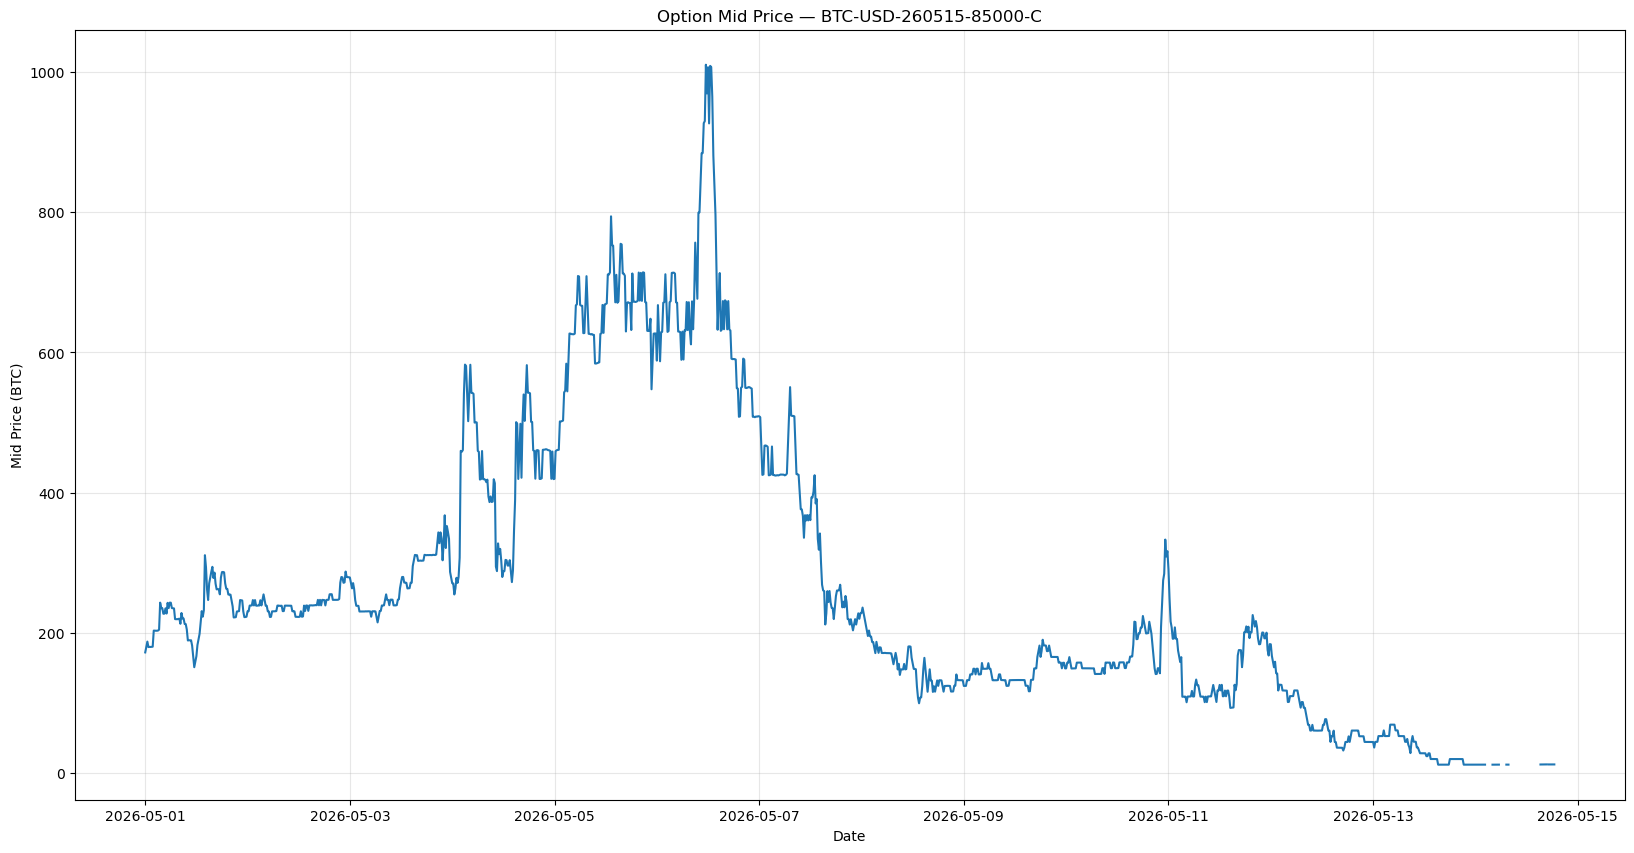

In [50]:
plt.figure(figsize=(20, 10))
plt.plot(contract_mid_snap['ts'], contract_mid_snap['mid_usd'])
plt.title('Option Mid Price — BTC-USD-260515-85000-C')
plt.xlabel('Date')
plt.ylabel('Mid Price (BTC)')
plt.grid(alpha=0.3)
plt.show()

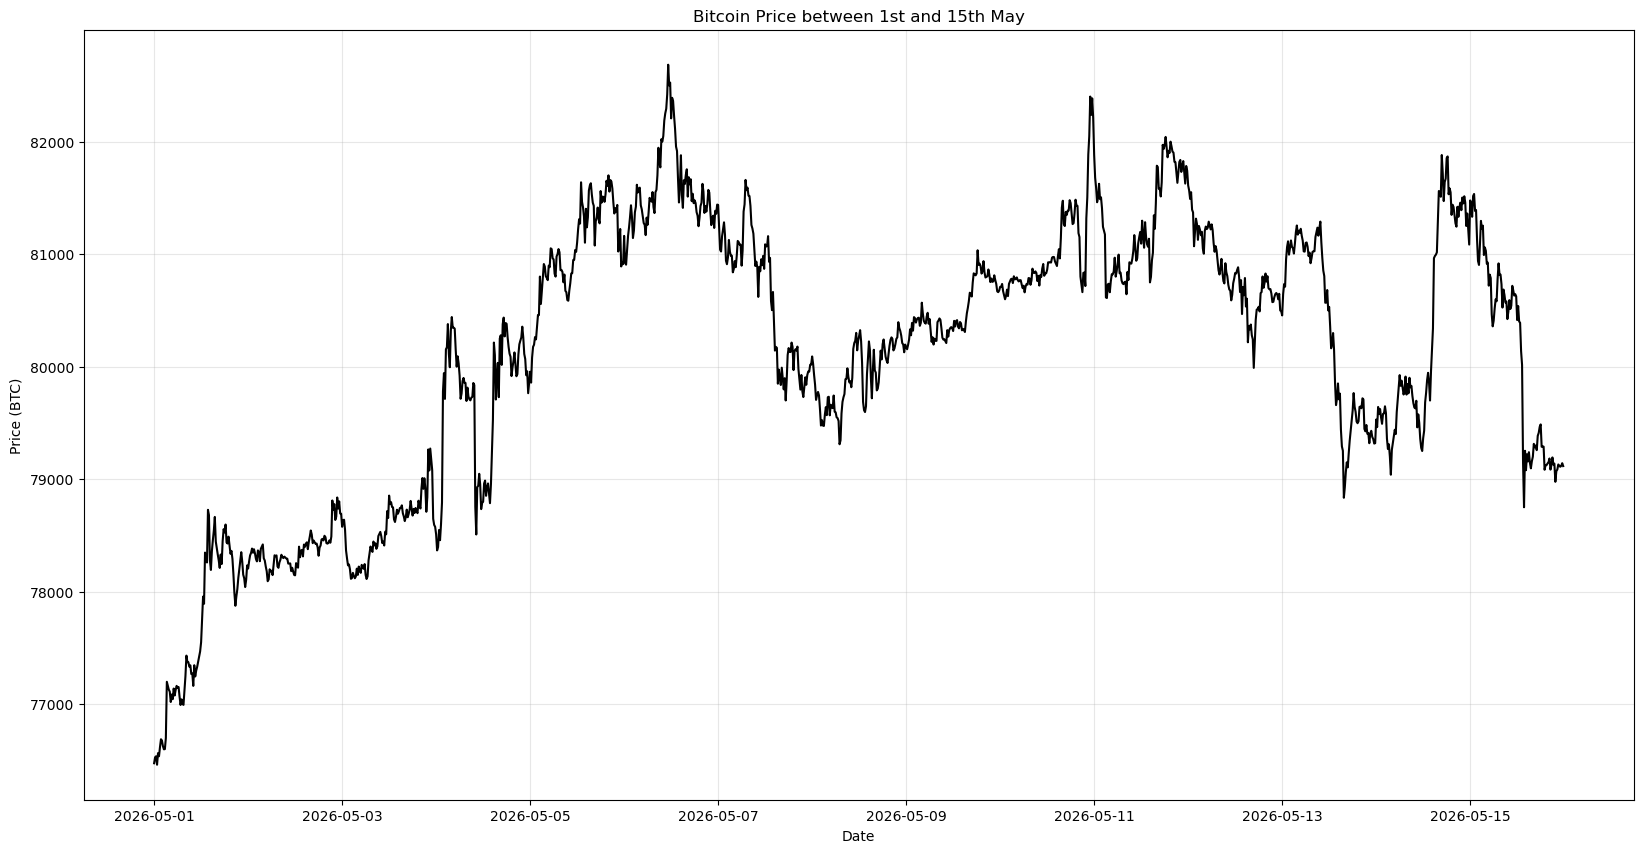

In [55]:
plt.figure(figsize=(20, 10))
plt.plot(btc_spot['ts'], btc_spot['btc_spot'], color='black')
plt.title('Bitcoin Price between 1st and 15th May')
plt.xlabel('Date')
plt.ylabel('Price (BTC)')
plt.grid(alpha=0.3)
plt.show()

In [210]:
trades_contract = trades[trades['instrument_name'] == contract_name]
as_df = pd.merge_asof(
    trades_contract.sort_values('ts'),
    contract_mid_snap.sort_values('ts'),
    on='ts',
    direction='backward'
).dropna()
as_df = as_df.drop(columns = ['instrument_name', 'instId', 'asks', 'bids', 'created_time', 'action'])
as_df_train = as_df[as_df['ts'].between('2026-05-01', '2026-05-11 00:00')].copy()
as_df_test = as_df[as_df['ts'].between('2026-05-11', '2026-05-15')].copy()

In [211]:
as_df_train['best_bid_usd'] = as_df_train['best_bid'] * as_df_train['btc_spot']
as_df_train['best_ask_usd'] = as_df_train['best_ask'] * as_df_train['btc_spot']
as_df_train['mid_usd']      = as_df_train['mid'] * as_df_train['btc_spot']
as_df_train['delta_bid']    = as_df_train['mid_usd'] - as_df_train['best_bid_usd']
as_df_train['delta_ask']    = as_df_train['best_ask_usd'] - as_df_train['mid_usd']

In [228]:
import torch

# separate bid and ask
bid_deltas = torch.tensor(
    as_df_train[as_df_train['side']=='sell']['delta_bid'].values, 
    dtype=torch.float32
)
ask_deltas = torch.tensor(
    as_df_train[as_df_train['side']=='buy']['delta_ask'].values, 
    dtype=torch.float32
)

def fit_intensity(deltas, T):
    # parameters — use softplus to keep positive
    log_A     = torch.tensor(0.0, requires_grad=True)
    log_kappa = torch.tensor(8.0, requires_grad=True)
    
    optimizer = torch.optim.Adam([log_A, log_kappa], lr=0.01)
    
    for step in range(2000):
        optimizer.zero_grad()
        
        A     = torch.exp(log_A)
        kappa = torch.exp(log_kappa)
        
        # negative log likelihood
        log_intensities = torch.log(A) - kappa * deltas
        integral        = A * T / kappa
        neg_ll          = -log_intensities.sum() + integral
        
        neg_ll.backward()
        optimizer.step()
        
        if step % 500 == 0:
            print(f"step {step}: A={A.item():.6f} kappa={kappa.item():.1f} nll={neg_ll.item():.2f}")
    
    return A.item(), kappa.item()

T = (as_df_train['ts'].max() - as_df_train['ts'].min()).total_seconds()

print("=== BID SIDE ===")
A_bid, kappa_bid = fit_intensity(bid_deltas, T)

print("\n=== ASK SIDE ===")
A_ask, kappa_ask = fit_intensity(ask_deltas, T)

print(f"\nFitted parameters:")
print(f"Bid: A={A_bid:.6f}, kappa={kappa_bid:.1f}")
print(f"Ask: A={A_ask:.6f}, kappa={kappa_ask:.1f}")

=== BID SIDE ===
step 0: A=1.000000 kappa=2981.0 nll=24490536.00
step 500: A=0.151506 kappa=249.3 nll=2049561.12
step 1000: A=0.055228 kappa=92.4 nll=761092.38
step 1500: A=0.028551 kappa=48.0 nll=396584.69

=== ASK SIDE ===
step 0: A=1.000000 kappa=2981.0 nll=5343632.50
step 500: A=0.050192 kappa=249.3 nll=447499.31
step 1000: A=0.017226 kappa=92.4 nll=166421.81
step 1500: A=0.008762 kappa=48.0 nll=86920.85

Fitted parameters:
Bid: A=0.017189, kappa=29.0
Ask: A=0.005240, kappa=29.0


In [229]:
def chi2_test(deltas, A, kappa, T, n_bins=10):
    counts, bin_edges = np.histogram(deltas, bins=n_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]
    
    expected = A * np.exp(-kappa * bin_centers) * bin_width * T
    
    # remove bins with expected < 5 first
    mask     = expected >= 5
    observed = counts[mask].astype(float)
    expected = expected[mask]
    
    # normalize after masking
    expected = expected * (observed.sum() / expected.sum())
    
    from scipy.stats import chisquare
    stat, p_value = chisquare(observed, expected)
    print(f"Chi2 stat: {stat:.3f}, p-value: {p_value:.4f}")
    print(f"{'Reject' if p_value < 0.05 else 'Fail to reject'} exponential assumption at 5% level")
    return stat, p_value

In [230]:
print("Bid side:")
chi2_test(
    as_df_train[as_df_train['side']=='sell']['delta_bid'].values,
    A_bid, kappa_bid, T
)

print("Ask side:")
chi2_test(
    as_df_train[as_df_train['side']=='buy']['delta_ask'].values,
    A_ask, kappa_ask, T,
    n_bins=3  # fewer bins given sparse data
)

Bid side:
Chi2 stat: 0.000, p-value: nan
Fail to reject exponential assumption at 5% level
Ask side:
Chi2 stat: 0.000, p-value: nan
Fail to reject exponential assumption at 5% level


/var/folders/rq/dq8_spf15q96_fxp3m4ggdjh0000gn/T/ipykernel_18232/850779010.py:14: RuntimeWarning: invalid value encountered in scalar divide
  expected = expected * (observed.sum() / expected.sum())


(np.float64(0.0), np.float64(nan))

**Q3 A-S Simulation**

In [82]:
expiry_str    = contract_name.split('-')[2]  # '260529'
expiry_date   = pd.Timestamp(f'20{expiry_str[:2]}-{expiry_str[2:4]}-{expiry_str[4:]}')

# simulation start
start_date = as_df_train['ts'].iloc[0]
T_expiry   = (expiry_date - start_date).total_seconds()

In [83]:
gamma   = 0.1
S0      = as_df_train['mid_usd'].iloc[-1]
dt      = 15 * 60              # 15-minute steps = 900 seconds
T       = 5 * 24 * 3600        # 4 days in seconds
n_steps = int(T / dt)          # 384 steps
tau     = 600                  # 1 interval = 15 minutes risk horizon

df = as_df_train.sort_values('ts').copy()
df['t']   = (df['ts'] - df['ts'].iloc[0]).dt.total_seconds()
dt_arr    = df['t'].diff().dropna().values
dt_arr    = np.clip(dt_arr, 1e-3, 3600)   # cap at 1 hour
dprice    = df['mid_usd'].diff().dropna().values

sigma = np.std(dprice / np.sqrt(dt_arr))

print(f"n_steps : {n_steps}")
print(f"S0      : {S0:.2f}")
print(f"sigma   : {sigma:.4f}")
print(f"tau     : {tau}")
print(f"gamma*sigma^2*tau : {gamma * sigma**2 * tau:.4f}")

n_steps : 480
S0      : 308.94
sigma   : 0.7510
tau     : 600
gamma*sigma^2*tau : 33.8436


In [84]:
bid_deltas_np = as_df_train[as_df_train['side']=='sell']['delta_bid'].values
ask_deltas_np = as_df_train[as_df_train['side']=='buy']['delta_ask'].values
T_train       = (as_df_train['ts'].max() - as_df_train['ts'].min()).total_seconds()

sigma = sigma

A_bid     = len(bid_deltas_np) / T_train
A_ask     = len(ask_deltas_np) / T_train

print(f"Bid: A={A_bid:.6f}, kappa={kappa_bid:.1f}")
print(f"Ask: A={A_ask:.6f}, kappa={kappa_ask:.1f}")

Bid: A=0.000592, kappa=29.0
Ask: A=0.000179, kappa=29.0


In [85]:
def generate_price_path(S0, sigma, dt, n_steps):
    dW = np.random.randn(n_steps) * np.sqrt(dt)
    W  = np.cumsum(dW)
    S  = S0 + sigma * W
    S  = np.maximum(S, 1e-6)  # floor at near-zero
    return np.concatenate([[S0], S])

In [86]:
def compute_quotes(S, q, gamma, sigma, tau, kappa_bid, kappa_ask):
    r = S - q * gamma * sigma**2 * tau
    delta_bid = (1/gamma) * np.log(1 + gamma/kappa_bid) + (gamma * sigma**2 / 2) * tau
    delta_ask = (1/gamma) * np.log(1 + gamma/kappa_ask) + (gamma * sigma**2 / 2) * tau
    bid       = r - delta_bid
    ask       = r + delta_ask
    return r, bid, ask, delta_bid, delta_ask

In [87]:
def simulate_fills(bid, ask, S, A_bid, kappa_bid, A_ask, kappa_ask, dt):
    
    lam_bid = A_bid * np.exp(-kappa_bid * max(S - bid, 0))
    lam_ask = A_ask * np.exp(-kappa_ask * max(ask - S, 0))
    
    # exact Poisson probability: P(at least one fill) = 1 - exp(-lambda * dt)
    p_bid = 1 - np.exp(-lam_bid * dt)
    p_ask = 1 - np.exp(-lam_ask * dt)
    
    bid_filled = np.random.random() < p_bid
    ask_filled = np.random.random() < p_ask
    
    return bid_filled, ask_filled

In [88]:
def simulate_path(price_path, sigma, gamma, tau, A_bid, kappa_bid, A_ask, kappa_ask, dt):
    S_path   = price_path
    n_steps = len(S_path) - 1
    
    q, X     = 0, 0.0
    q_path        = [0]
    cash_pnl_path = [0.0]   # spread income only
    mtm_path      = [0.0]   # total mark-to-market
    
    for t in range(n_steps):
        S = S_path[t]
        
        r, bid, ask, db, da = compute_quotes(S, q, gamma, sigma, tau, kappa_bid, kappa_ask)
        bid_filled, ask_filled = simulate_fills(bid, ask, S, A_bid, kappa_bid, A_ask, kappa_ask, dt)
        
        if bid_filled:
            q += 1
            X -= bid
        if ask_filled:
            q -= 1
            X += ask
        
        S_next = S_path[t + 1] if t + 1 < len(S_path) else S
        
        q_path.append(q)
        cash_pnl_path.append(X)
        mtm_path.append(X + q * S_next)
    
    return np.array(q_path), np.array(cash_pnl_path), np.array(mtm_path)

In [89]:
def simulate_path_symmetric(price_path, sigma, gamma, tau, A_sym, kappa_sym, dt):
    S_path      = price_path
    n_steps = len(S_path) - 1
    
    q, X        = 0, 0.0
    q_path      = [0]
    cash_pnl_path = [0.0]
    mtm_path    = [0.0]
    
    half_spread = (1/gamma) * np.log(1 + gamma/kappa_sym)
    
    for t in range(n_steps):
        S   = S_path[t]
        bid = max(S - half_spread, 1e-6)
        ask = S + half_spread
        
        bid_filled, ask_filled = simulate_fills(
            bid, ask, S, A_sym, kappa_sym, A_sym, kappa_sym, dt
        )
        if bid_filled:
            q += 1;  X -= bid
        if ask_filled:
            q -= 1;  X += ask
        
        S_next = S_path[t+1] if t+1 < len(S_path) else S
        q_path.append(q)
        cash_pnl_path.append(X)
        mtm_path.append(X + q * S_next)
    
    return np.array(q_path), np.array(cash_pnl_path), np.array(mtm_path)

# run symmetric

In [90]:
A_sym     = A_bid
kappa_sym = (kappa_bid + kappa_ask) / 2
n_steps_sim = int(4 * 24 * 3600 / dt)  # 345,600 steps
S_path = generate_price_path(S0, sigma, dt, n_steps_sim)

q_path, cash_pnl_path, mtm_path = simulate_path(
    S_path, sigma, gamma, tau,
    A_sym, kappa_sym,
    A_sym, kappa_sym,
    dt
)

q_path_sym, cash_sym, mtm_sym = simulate_path_symmetric(
    S_path, sigma, gamma, tau, A_sym, kappa_sym, dt
)

In [99]:
r, bid, ask, delta_bid, delta_ask = compute_quotes(S0, 0, gamma, sigma_sim, tau, kappa_sym, kappa_sym)

lam_bid = A_sym * np.exp(-kappa_sym * max(S0 - bid, 0))
lam_ask = A_sym * np.exp(-kappa_sym * max(ask - S0, 0))

p_bid = 1 - np.exp(-lam_bid * dt)
p_ask = 1 - np.exp(-lam_ask * dt)

print(f"S0         : {S0:.4f}")
print(f"bid        : {bid:.4f}")
print(f"ask        : {ask:.4f}")
print(f"delta_bid  : {delta_bid:.4f}")
print(f"S0 - bid   : {S0 - bid:.4f}")
print(f"kappa*delta: {kappa_sym * delta_bid:.4f}")
print(f"lam_bid    : {lam_bid:.8f}")
print(f"p_bid (dt) : {p_bid:.8f}")
print(f"fills/day  : {lam_bid * 86400:.2f}")

S0         : 308.9393
bid        : 298.9052
ask        : 318.9733
delta_bid  : 10.0341
S0 - bid   : 10.0341
kappa*delta: 290.5601
lam_bid    : 0.00000000
p_bid (dt) : 0.00000000
fills/day  : 0.00


In [ ]:
print(f"kappa_sym : {kappa_sym:.6f}")
print(f"A_sym     : {A_sym:.6f}")
print(f"sigma_sim : {sigma_sim:.6f}")
print(f"tau       : {tau}")

/var/folders/rq/dq8_spf15q96_fxp3m4ggdjh0000gn/T/ipykernel_21385/3632314650.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


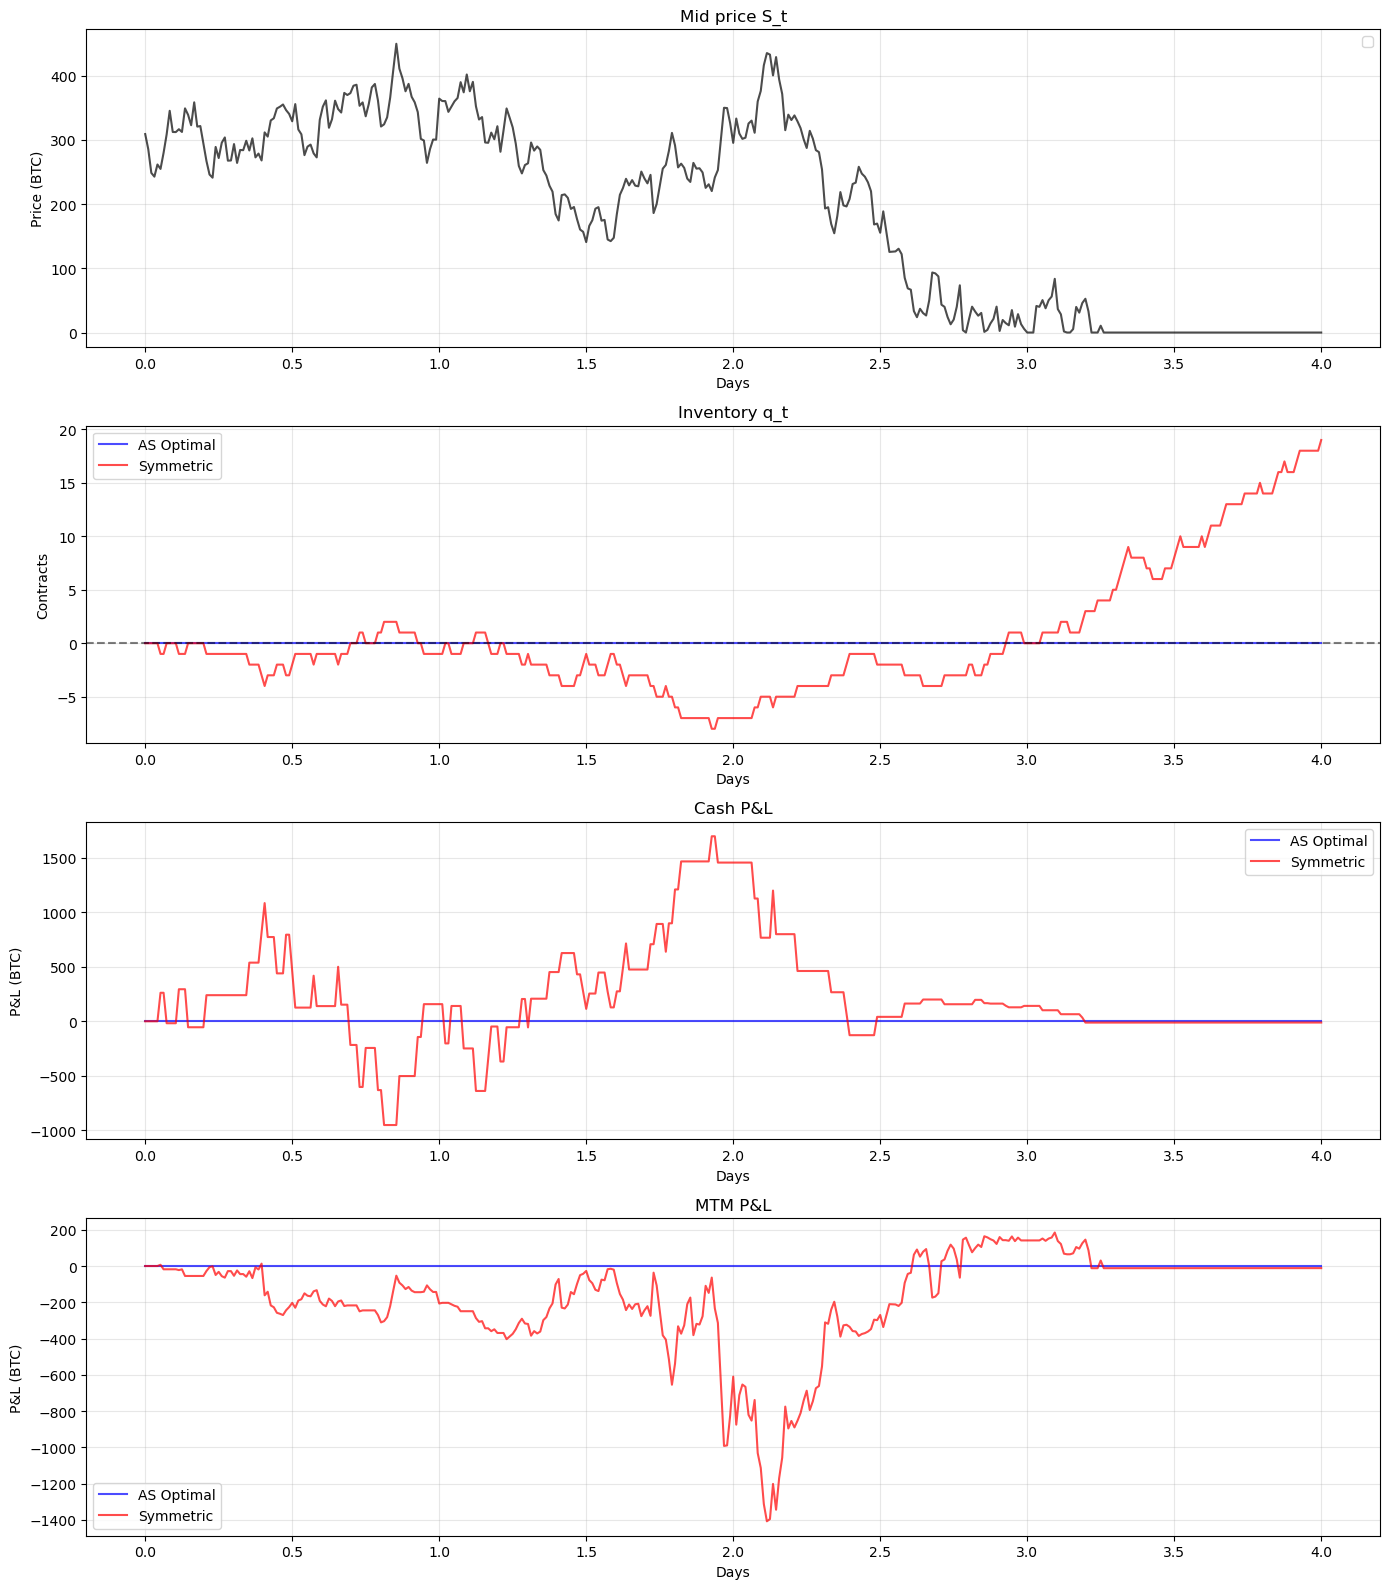

In [91]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

t = np.arange(len(q_path)) / (24 * 3600 / dt)

axes[0].plot(t, S_path[:len(q_path)], alpha=0.7, color='black', )

axes[1].plot(t, q_path,     alpha=0.7, label='AS Optimal', color='blue')
axes[1].plot(t, q_path_sym, alpha=0.7, label='Symmetric',  color='red')

axes[2].plot(t, cash_pnl_path, alpha=0.7, label='AS Optimal', color='blue')
axes[2].plot(t, cash_sym,      alpha=0.7, label='Symmetric',  color='red')

axes[3].plot(t, mtm_path, alpha=0.7, label='AS Optimal', color='blue')
axes[3].plot(t, mtm_sym,  alpha=0.7, label='Symmetric',  color='red')

axes[0].set_title('Mid price S_t');    axes[0].set_ylabel('Price (BTC)')
axes[1].set_title('Inventory q_t');    axes[1].set_ylabel('Contracts')
axes[2].set_title('Cash P&L');         axes[2].set_ylabel('P&L (BTC)')
axes[3].set_title('MTM P&L');          axes[3].set_ylabel('P&L (BTC)')

axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)

for ax in axes:
    ax.set_xlabel('Days')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [92]:
def generate_gbm_price_path(S0, sigma_sim, dt, n_steps):
    # sigma_sim is already USD/second
    # convert to fractional vol per step
    sigma_pct = sigma_sim / S0          
    dW        = np.random.randn(n_steps) * np.sqrt(dt)
    # drift correction
    log_S = np.log(S0) + np.cumsum(
        -0.5 * sigma_pct**2 * dt + sigma_pct * dW
    )
    S = np.exp(log_S)
    return np.concatenate([[S0], S])

In [93]:
# cap so 4-day range is at most 3x S0
max_log_return = np.log(3)  # allow up to 3x move
sigma_sim = S0 * max_log_return / np.sqrt(4 * 24 * 3600)

print(f"sigma_sim : {sigma_sim:.6f}")
print(f"sigma_sim/S0 * sqrt(T): {sigma_sim/S0 * np.sqrt(4*24*3600):.4f}")
print(f"expected max range: {S0 * np.exp(sigma_sim/S0 * np.sqrt(4*24*3600)):.2f} USD")

S_gbm_path = generate_gbm_price_path(S0, sigma_sim, dt, n_steps_sim)

sigma_sim : 0.577339
sigma_sim/S0 * sqrt(T): 1.0986
expected max range: 926.82 USD


In [94]:
q_gbm_path, cash_pnl_gbm_path, mtm_gbm_path = simulate_path(
    S_gbm_path, sigma_sim, gamma, tau,    # ← sigma_sim not sigma
    A_sym, kappa_sym,
    A_sym, kappa_sym,
    dt
)

q_gbm_path_sym, cash_sym, mtm_sym = simulate_path_symmetric(
    S_gbm_path, sigma_sim, gamma, tau, A_sym, kappa_sym, dt    # ← sigma_sim
)

/var/folders/rq/dq8_spf15q96_fxp3m4ggdjh0000gn/T/ipykernel_21385/2232079467.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


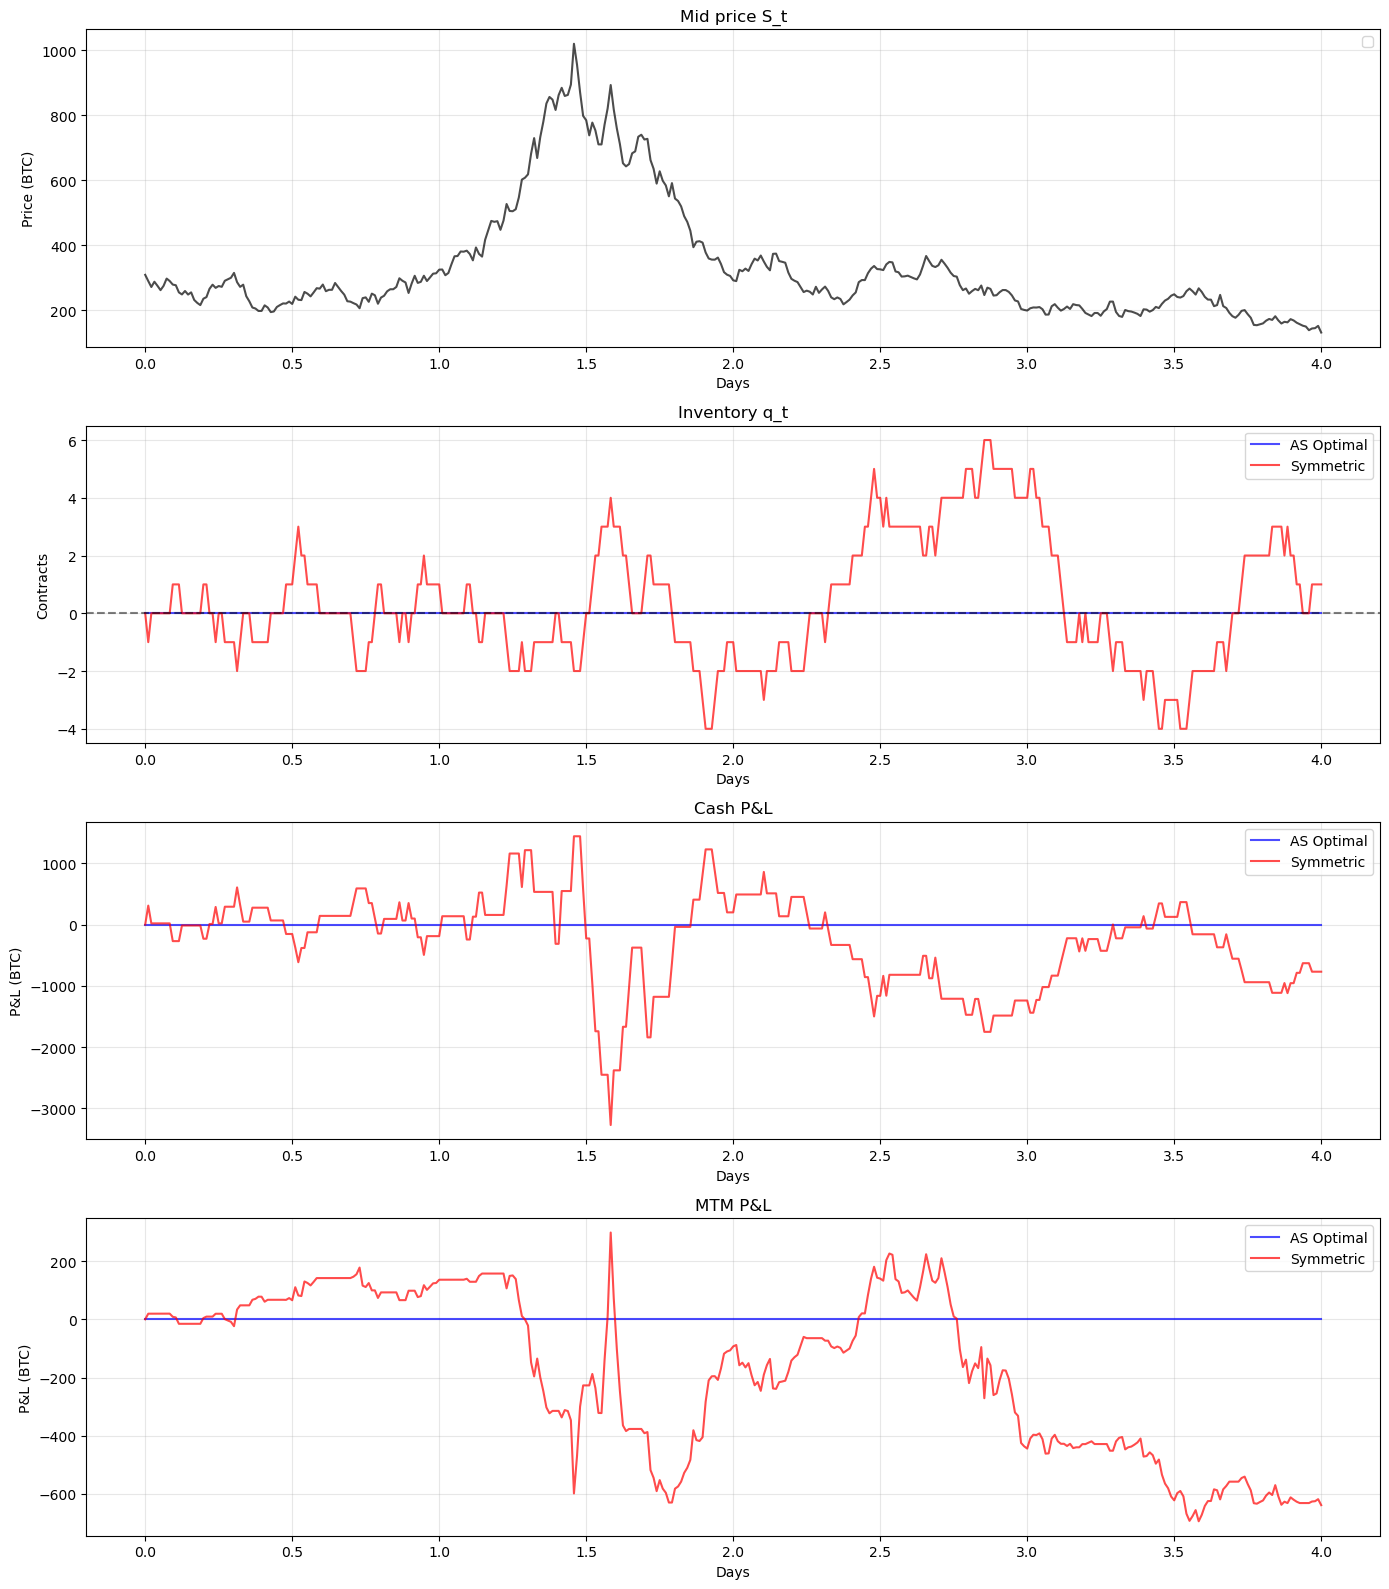

In [95]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

t = np.arange(len(q_gbm_path)) / (24 * 3600 / dt)

axes[0].plot(t, S_gbm_path[:len(q_gbm_path)], alpha=0.7, color='black')

axes[1].plot(t, q_gbm_path,     alpha=0.7, label='AS Optimal', color='blue')
axes[1].plot(t, q_gbm_path_sym, alpha=0.7, label='Symmetric',  color='red')

axes[2].plot(t, cash_pnl_gbm_path, alpha=0.7, label='AS Optimal', color='blue')
axes[2].plot(t, cash_sym,      alpha=0.7, label='Symmetric',  color='red')

axes[3].plot(t, mtm_gbm_path, alpha=0.7, label='AS Optimal', color='blue')
axes[3].plot(t, mtm_sym,  alpha=0.7, label='Symmetric',  color='red')

axes[0].set_title('Mid price S_t');    axes[0].set_ylabel('Price (BTC)')
axes[1].set_title('Inventory q_t');    axes[1].set_ylabel('Contracts')
axes[2].set_title('Cash P&L');         axes[2].set_ylabel('P&L (BTC)')
axes[3].set_title('MTM P&L');          axes[3].set_ylabel('P&L (BTC)')

axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)

for ax in axes:
    ax.set_xlabel('Days')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**BackTest**

=== AS Optimal ===
Final P&L      : -243.2097 USD
Mean inventory : 0.0420
Std inventory  : 0.6421

=== Symmetric ===
Final P&L      : -8509.1443 USD
Mean inventory : 94.3182
Std inventory  : 48.6021


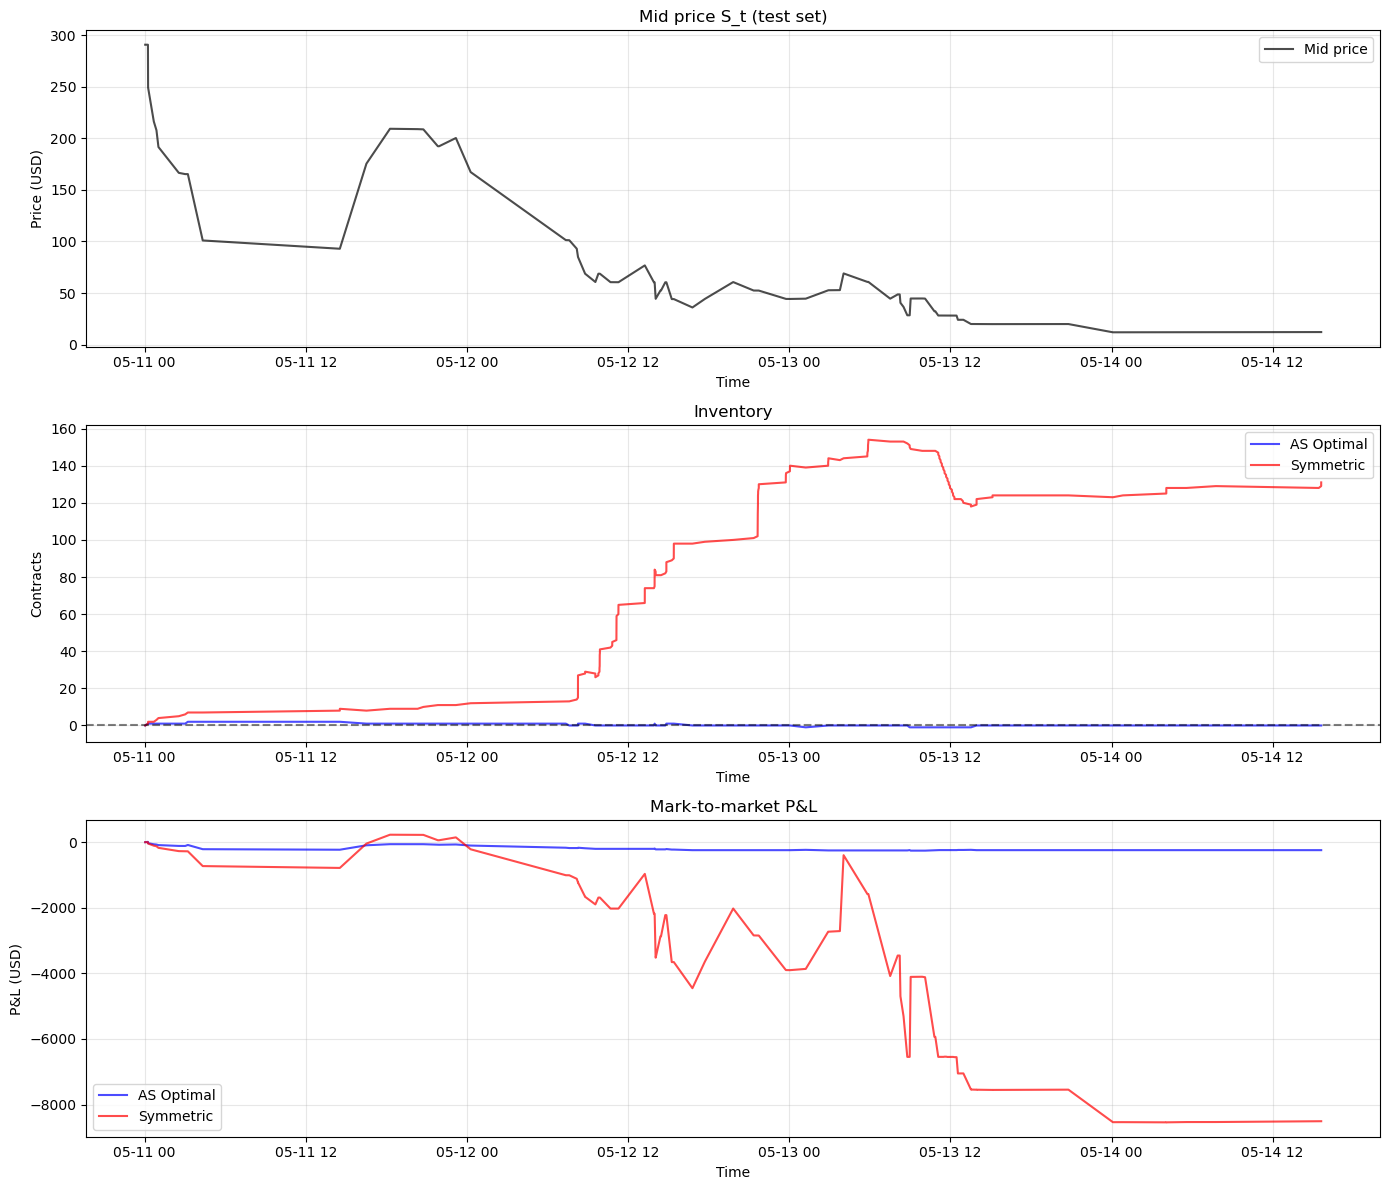

In [96]:
# ── Quote functions ───────────────────────────────────────────────────────────

def as_quote_fn(mid, q, gamma, sigma, kappa, tau):
    r           = mid - q * gamma * sigma**2 * tau
    half_spread = (1/gamma) * np.log(1 + gamma/kappa) + (gamma * sigma**2 / 2) * tau
    half_spread = min(half_spread, 0.5 * mid)
    bid         = max(r - half_spread, 1e-6)
    ask         = r + half_spread
    return bid, ask

def symmetric_quote_fn(mid, q, gamma, sigma, kappa, tau):
    half_spread = (1/gamma) * np.log(1 + gamma/kappa)
    bid         = max(mid - half_spread, 1e-6)
    ask         = mid + half_spread
    return bid, ask


# ── Backtest ──────────────────────────────────────────────────────────────────

def run_backtest(df, quote_fn, gamma, sigma, kappa, tau):
    cash, inventory = 0.0, 0.0
    records = []

    for _, row in df.iterrows():
        mid         = row['mid_usd']
        trade_price = row['price'] * row['btc_spot']
        trade_side  = row['side']

        bid, ask = quote_fn(mid, inventory, gamma, sigma, kappa, tau)

        if trade_side == 'buy' and trade_price >= ask:
            inventory -= 1;  cash += ask
        elif trade_side == 'sell' and trade_price <= bid:
            inventory += 1;  cash -= bid

        records.append({
            'ts'       : row['ts'],
            'mid'      : mid,
            'bid'      : bid,
            'ask'      : ask,
            'inventory': inventory,
            'cash'     : cash,
            'pnl'      : cash + inventory * mid
        })

    return pd.DataFrame(records)


# ── Run both strategies ───────────────────────────────────────────────────────

opt_result  = run_backtest(as_df_test, as_quote_fn,        gamma, sigma_sim, kappa_sym, tau)
base_result = run_backtest(as_df_test, symmetric_quote_fn, gamma, sigma_sim, kappa_sym, tau)

print("=== AS Optimal ===")
print(f"Final P&L      : {opt_result['pnl'].iloc[-1]:.4f} USD")
print(f"Mean inventory : {opt_result['inventory'].mean():.4f}")
print(f"Std inventory  : {opt_result['inventory'].std():.4f}")

print("\n=== Symmetric ===")
print(f"Final P&L      : {base_result['pnl'].iloc[-1]:.4f} USD")
print(f"Mean inventory : {base_result['inventory'].mean():.4f}")
print(f"Std inventory  : {base_result['inventory'].std():.4f}")


# ── Plots ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

t_opt  = opt_result['ts']
t_base = base_result['ts']

# mid price
axes[0].plot(t_opt, opt_result['mid'], color='black', alpha=0.7, label='Mid price')
axes[0].set_title('Mid price S_t (test set)')
axes[0].set_ylabel('Price (USD)')

# inventory
axes[1].plot(t_opt,  opt_result['inventory'],  color='blue', alpha=0.7, label='AS Optimal')
axes[1].plot(t_base, base_result['inventory'], color='red',  alpha=0.7, label='Symmetric')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Inventory')
axes[1].set_ylabel('Contracts')

# P&L
axes[2].plot(t_opt,  opt_result['pnl'],  color='blue', alpha=0.7, label='AS Optimal')
axes[2].plot(t_base, base_result['pnl'], color='red',  alpha=0.7, label='Symmetric')
axes[2].set_title('Mark-to-market P&L')
axes[2].set_ylabel('P&L (USD)')

for ax in axes:
    ax.set_xlabel('Time')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [97]:
print(f"AS  final P&L      : {opt_result['pnl'].iloc[-1]:.2f} USD")
print(f"Sym final P&L      : {base_result['pnl'].iloc[-1]:.2f} USD")
print(f"AS  inventory std  : {opt_result['inventory'].std():.4f}")
print(f"Sym inventory std  : {base_result['inventory'].std():.4f}")
print(f"AS  max inventory  : {opt_result['inventory'].max():.0f}")
print(f"Sym max inventory  : {base_result['inventory'].max():.0f}")

AS  final P&L      : -243.21 USD
Sym final P&L      : -8509.14 USD
AS  inventory std  : 0.6421
Sym inventory std  : 48.6021
AS  max inventory  : 2
Sym max inventory  : 154
